# Phase 3: Rekayasa Fitur & Analisis Korelasi (Feature Engineering & EDA)

Notebook ini berfokus pada pembentukan fitur spasial dan temporal (seperti jam, hari, bulan), analisis deskriptif, korelasi antar variabel, dan penyiapan dataset akhir untuk pemodelan.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style visualisasi
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams['figure.dpi'] = 100

# Load dataset bersih dari Phase 2
clean_data_path = os.path.join('data', 'clean_imputed_data.csv')
df = pd.read_csv(clean_data_path)
df['waktu'] = pd.to_datetime(df['waktu'])

print("Dataset Berhasil Dimuat:")
print(df.info())

Dataset Berhasil Dimuat:
<class 'pandas.DataFrame'>
RangeIndex: 131640 entries, 0 to 131639
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   waktu                 131640 non-null  datetime64[us]
 1   PM2.5                 131640 non-null  float64       
 2   stasiun               131640 non-null  str           
 3   temperature_2m        131640 non-null  float64       
 4   apparent_temperature  131640 non-null  float64       
 5   relative_humidity_2m  131640 non-null  int64         
 6   dew_point_2m          131640 non-null  float64       
 7   precipitation         131640 non-null  float64       
 8   rain                  131640 non-null  float64       
 9   surface_pressure      131640 non-null  float64       
 10  cloud_cover_total     131640 non-null  int64         
 11  wind_speed_10m        131640 non-null  float64       
 12  wind_direction_10m    131640 non-null  int64

## Dekomposisi Vektor Angin (Wind Vector Decomposition)

Arah angin (0° - 360°) adalah fitur sirkular. Random Forest (pohon keputusan) membagi data secara linier, sehingga ia tidak tahu bahwa 359° secara fisis sangat dekat dengan 1°. 
Kita mengubah kecepatan angin (`wind_speed_10m`) dan arah angin (`wind_direction_10m`) menjadi komponen vektor:
* $u\_wind = wind\_speed \times \cos(\theta_{rad})$ (Komponen angin Timur-Barat)
* $v\_wind = wind\_speed \times \sin(\theta_{rad})$ (Komponen angin Utara-Selatan)

In [3]:
# 1. Ubah arah angin dari derajat ke radian
wind_dir_rad = np.radians(df['wind_direction_10m'])

# 2. Hitung komponen vektor u dan v
df['u_wind'] = df['wind_speed_10m'] * np.cos(wind_dir_rad)
df['v_wind'] = df['wind_speed_10m'] * np.sin(wind_dir_rad)

# 3. Hapus kolom angin asli untuk menghindari redundansi
df_features = df.drop(columns=['wind_speed_10m', 'wind_direction_10m'])

print("Kolom setelah dekomposisi angin:")
print(df_features.columns.tolist())

Kolom setelah dekomposisi angin:
['waktu', 'PM2.5', 'stasiun', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'rain', 'surface_pressure', 'cloud_cover_total', 'AOD', 'latitude', 'longitude', 'u_wind', 'v_wind']


## Ekstraksi Fitur Temporal

Kita mengekstrak fitur waktu untuk membantu RFR mendeteksi pola temporal polusi (jam sibuk vs tengah malam, serta variasi musiman):
* `jam` (0 - 23)
* `bulan` (1 - 12)
* `hari_dalam_minggu` (0 - 6, di mana 0 = Senin, 6 = Minggu)
* `is_weekend` (1 jika hari Sabtu/Minggu, 0 jika hari kerja)

In [4]:
# Ekstrak fitur temporal
df_features['jam'] = df_features['waktu'].dt.hour
df_features['bulan'] = df_features['waktu'].dt.month
df_features['hari_dalam_minggu'] = df_features['waktu'].dt.dayofweek

# Buat fitur is_weekend (Sabtu = 5, Minggu = 6)
df_features['is_weekend'] = df_features['hari_dalam_minggu'].apply(lambda x: 1 if x >= 5 else 0)

print("Statistik Fitur Temporal:")
print(df_features[['jam', 'bulan', 'hari_dalam_minggu', 'is_weekend']].describe())

Statistik Fitur Temporal:
                 jam          bulan  hari_dalam_minggu     is_weekend
count  131640.000000  131640.000000      131640.000000  131640.000000
mean       11.500000       6.516864           2.997265       0.285324
std         6.922213       3.451452           2.000689       0.451570
min         0.000000       1.000000           0.000000       0.000000
25%         5.750000       4.000000           1.000000       0.000000
50%        11.500000       7.000000           3.000000       0.000000
75%        17.250000      10.000000           5.000000       1.000000
max        23.000000      12.000000           6.000000       1.000000


## Matriks Korelasi & Heatmap Global

✓ Gambar heatmap korelasi berhasil disimpan di: results\images\correlation_matrix.png


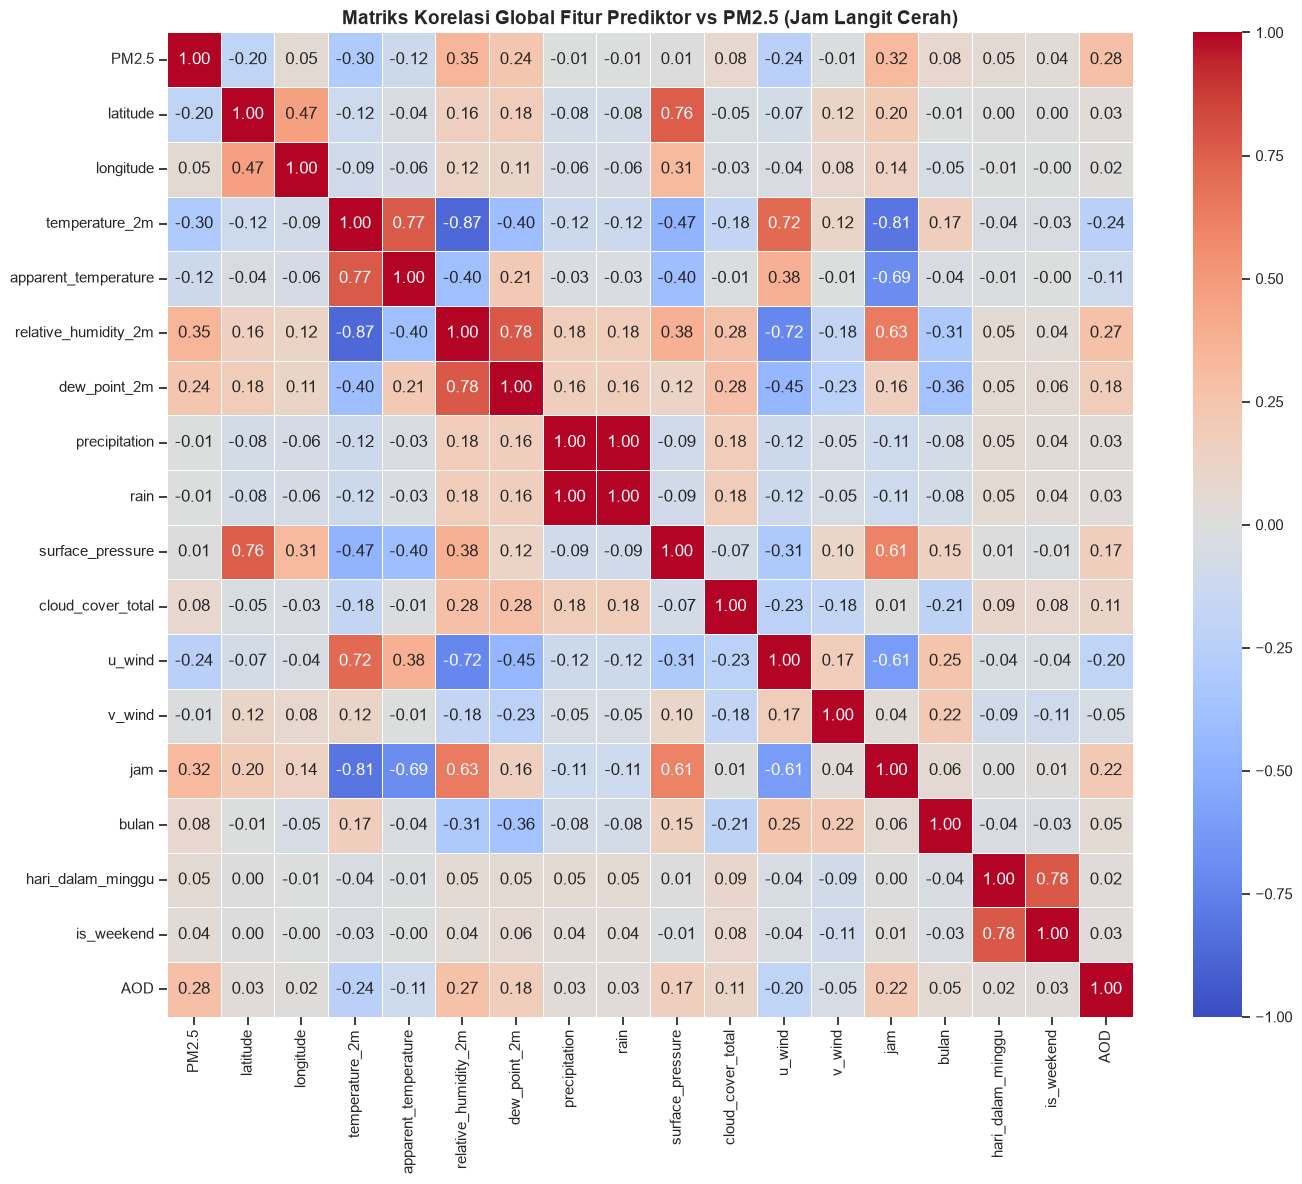

In [ ]:
# Kumpulkan hanya kolom numerik untuk korelasi
numerical_cols = [
    'PM2.5', 'latitude', 'longitude', 'temperature_2m', 'apparent_temperature',
    'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'rain',
    'surface_pressure', 'cloud_cover_total', 'u_wind', 'v_wind',
    'jam', 'bulan', 'hari_dalam_minggu', 'is_weekend', 'AOD'
]

# Abaikan nilai AOD = -999.0 agar korelasi dihitung pada kondisi langit cerah riil
df_corr_sample = df_features[df_features['AOD'] != -999.0][numerical_cols]

# Hitung korelasi
corr_matrix = df_corr_sample.corr()

# Tampilkan Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriks Korelasi Global Fitur Prediktor vs PM2.5 (Jam Langit Cerah)', fontsize=14, fontweight='bold')

# AUTO-SAVE: Membuat folder results/images jika belum ada, lalu menyimpan plot
output_img_dir = os.path.join('results', 'images')
os.makedirs(output_img_dir, exist_ok=True)
output_img_path = os.path.join(output_img_dir, 'correlation_matrix.png')

plt.savefig(output_img_path, dpi=300, bbox_inches='tight')
print(f"✓ Gambar heatmap korelasi berhasil disimpan di: {output_img_path}")

plt.tight_layout()
plt.show()

## Simpan Dataset Model Ready

In [ ]:
# Tentukan daftar semua kolom yang akan disimpan (termasuk waktu dan stasiun sebagai label)
final_columns = [
    'waktu', 'stasiun', 'PM2.5', 'latitude', 'longitude',
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'dew_point_2m',
    'precipitation', 'rain', 'surface_pressure', 'cloud_cover_total',
    'u_wind', 'v_wind', 'jam', 'bulan', 'hari_dalam_minggu', 'is_weekend', 'AOD'
]

# Ambil kolom yang terpilih
df_model_ready = df_features[final_columns].copy()

# Simpan ke file master akhir
ready_output_path = os.path.join('data', 'model_ready_data.csv')
df_model_ready.to_csv(ready_output_path, index=False)

print(f"✓ BERHASIL! Dataset siap latih model disimpan di: {ready_output_path}")
print(f"Total baris: {len(df_model_ready)}")
print(f"Total kolom: {df_model_ready.shape[1]} (termasuk label 'waktu' dan 'stasiun')")
print("\nDaftar Kolom Akhir:")
print(df_model_ready.columns.tolist())

✓ BERHASIL! Dataset siap latih model disimpan di: data\model_ready_data.csv
Total baris: 131640
Total kolom: 20 (termasuk label 'waktu' dan 'stasiun')

Daftar Kolom Akhir:
['waktu', 'stasiun', 'PM2.5', 'latitude', 'longitude', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'rain', 'surface_pressure', 'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan', 'hari_dalam_minggu', 'is_weekend', 'AOD']
